<a href="https://colab.research.google.com/github/oridoll/Mini_projets/blob/test_vit_cnn/vit_vs_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VIT vs CNN

The objective of this project is to compare the performances of two differents architectures for the task of image classification: Vision Transformers (ViT) and Convolutional Neural Networks (CNN). A Convolutionnal Neural Networtk is a specialized neural network designed to classify and to process images by using a local information from adjacent pixels. Its firsts layers are a combination of Convolution and Pooling layers and the last layers are a fully-connected or dense layer. A Vision Transformer uses the auto-attention mechanism to consider the relationship between all the patches of the images. 
Acccording to this paper [An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale](https://doi.org/10.48550/arXiv.2010.11929) : CNN are better over small datasets thant ViT. This what we study in this notebook.

 It is better on small datasets because there is less global parameters to learn
 It needs a large quantity of data to learn these relations without the advantage of local induction.

### Comparison of the architecture of a CNN and a ViT

reprendre le cours et expliquer (c'est la question 2) "Make sure to explain the ViT architecture in detail." JE SAIS PAS SI LA LICENSE DE L'IMAGE ESST VALIDE https://github.com/google-research/vision_transformer

![ViT](vit.png "ViT")
![CNN](cnn_architecture.png "CNN")


### Choice of the two datasets

We chose to use the dataset CIFAR10 and STL10. We explain why below.

In [1]:
#%load_ext autoreload
#%autoreload 2

import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)



cuda


For the fisrt dataset, we propose CIFAR10 https://www.cs.toronto.edu/~kriz/cifar.html

| Shape | Number of classes | Dataset |
|:-------- |:--------:| --------:|
| 32 x 32 pixels RGB | 10   | 60000 images  |

The training dataset has 50000 images and the test dataset has 10000 images.
<p>Justification :

<p>Small images require low-level feature extraction. This allows testing whether a basic ViT (which uses large patches, e.g., 16x16) can outperform a CNN like LeNet or VGG on low-resolution images. This dataset has a small complexity so it can concentrate on the architecture over the rarity of the classes. A small volume of data allowed a fast training and i ideal to test models from scratch.

In [2]:
from torchvision import datasets, transforms

batch_size = 128

# Data loading - WITH CORRECT CIFAR-10 NORMALIZATION
# Standard CIFAR-10 statistics: mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]
transform_cifar10 = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])
train_dataset_cifar10 = datasets.CIFAR10(root='cifar10', train=True, transform=transform_cifar10, download=True)
test_dataset_cifar10 = datasets.CIFAR10(root='cifar10', train=False, transform=transform_cifar10, download=True)

train_loader_cifar10 = torch.utils.data.DataLoader(dataset=train_dataset_cifar10, batch_size=batch_size, shuffle=True)
test_loader_cifar10 = torch.utils.data.DataLoader(dataset=test_dataset_cifar10, batch_size=batch_size, shuffle=False)

100%|██████████| 170M/170M [05:14<00:00, 542kB/s] 


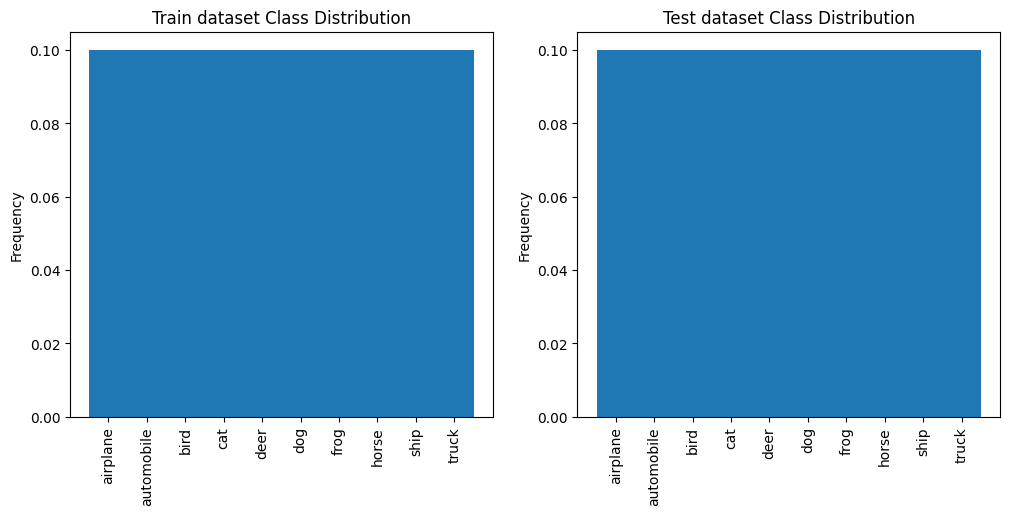

In [3]:
def get_data_statistics(dataset, ax, title):
    ax.hist(dataset.classes, bins=np.arange(11)-0.5, density=True)

    #plt.set_xticks(np.arange(10))
    #plt.set_xticklabels(list(dataset.classes))
    ax.set_ylabel('Frequency')
    ax.tick_params(axis='x', rotation=90)
    ax.set_title(title)
    

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
title_train = 'Train dataset Class Distribution'
title_test = 'Test dataset Class Distribution'
get_data_statistics(train_dataset_cifar10, ax1, title_train)
get_data_statistics(test_dataset_cifar10, ax2, title_test)
plt.show()

One can observe that we have a perfect repartition between all the classes for the training and test dataset.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0942786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9100897..2.100835].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7709224..1.7256967].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0432324].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594..2.0298588].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8465825..2.0137537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594

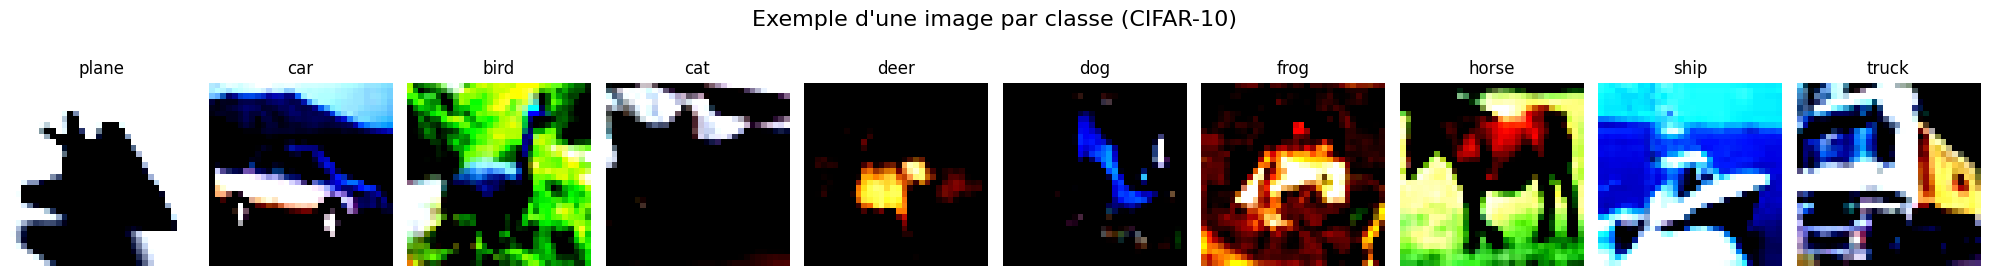


Dimensions d'une image (Tensor) : torch.Size([3, 32, 32])
Plage de valeurs d'un pixel (après ToTensor) : -1.9481 à 2.1104


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Classes from CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Collect the indexes of one image per class
num_classes = len(classes)
samples_per_class = 1
indices_to_display = {}

# Find an index per class
for i in range(len(train_dataset_cifar10)):
    _, label = train_dataset_cifar10[i]
    if label not in indices_to_display:
        indices_to_display[label] = i
        if len(indices_to_display) == num_classes:
            break

# Plot
fig, axes = plt.subplots(1, num_classes, figsize=(20, 3))
fig.suptitle("Exemple d'une image par classe (CIFAR-10)", fontsize=16)

for label, index in indices_to_display.items():
    image_tensor, _ = train_dataset_cifar10[index]
    image_np = image_tensor.numpy().transpose((1, 2, 0))

    # Plot
    ax = axes[label]
    ax.imshow(image_np)
    ax.set_title(classes[label])
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Print the Tensor of one images to check the dimensions and pixel value range
print(f"\nDimensions d'une image (Tensor) : {image_tensor.shape}")
print(f"Plage de valeurs d'un pixel (après ToTensor) : {image_tensor.min():.4f} à {image_tensor.max():.4f}")

For the second dataset, we propose STL10 https://cs.stanford.edu/~acoates/stl10/

| Shape | Number of classes | Dataset |
|:-------- |:--------:| --------:|
| 96 x 96 RGB | 10 |  images  |

The training dataset has 5000 images and the test dataset has 800 images.
<p>Justification :

<p>

In [5]:
from torchvision import datasets, transforms
import torch

batch_size = 64 # On réduit la taille du batch car les images sont plus grandes

# Standard normalization for STL-10
transform_stl10 = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.43, 0.43, 0.43], std=[0.27, 0.27, 0.27])])

# Chargement de STL-10
try:
    train_dataset_stl10 = datasets.STL10(root='data_stl10', split='train', transform=transform_stl10, download=True)
    test_dataset_stl10 = datasets.STL10(root='data_stl10', split='test',transform=transform_stl10, download=True)

# Création des DataLoaders
    train_loader_stl10 = torch.utils.data.DataLoader(dataset=train_dataset_stl10, batch_size=batch_size, shuffle=True)
    test_loader_stl10 = torch.utils.data.DataLoader(dataset=test_dataset_stl10, batch_size=batch_size, shuffle=False)

    print("STL-10 chargé avec succès.")
    print(f"Images d'entraînement (étiquetées) : {len(train_dataset_stl10)}")
    print(f"Dimensions de la première image (Tensor) : {train_dataset_stl10[0][0].shape}")

except RuntimeError as e:
    print(f"Erreur lors du téléchargement de STL-10 : {e}")
    print("Veuillez vérifier votre connexion ou si le téléchargement manuel est requis (peu probable pour STL-10).")

100%|██████████| 2.64G/2.64G [06:12<00:00, 7.09MB/s] 


STL-10 chargé avec succès.
Images d'entraînement (étiquetées) : 5000
Dimensions de la première image (Tensor) : torch.Size([3, 96, 96])


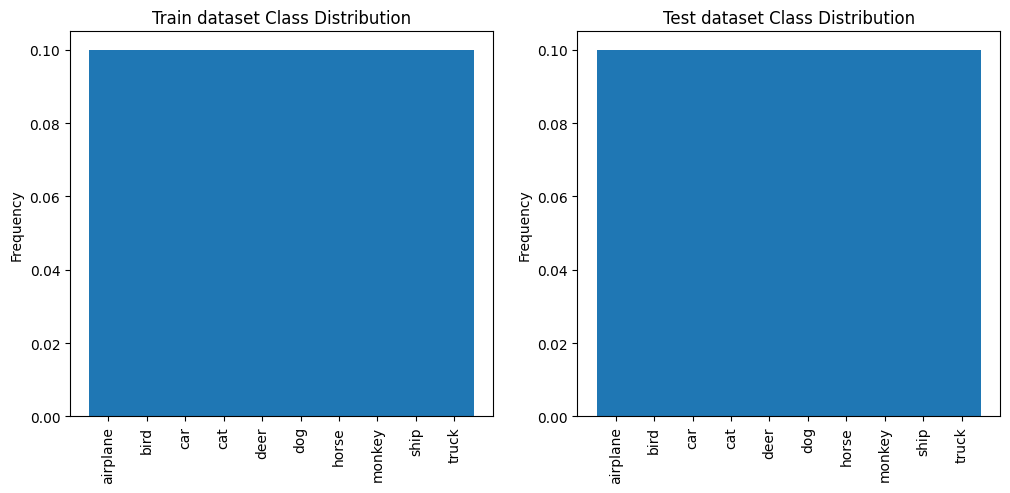

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
title_train = 'Train dataset Class Distribution'
title_test = 'Test dataset Class Distribution'
get_data_statistics(train_dataset_stl10, ax1, title_train)
get_data_statistics(test_dataset_stl10, ax2, title_test)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..1.5156136].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.0384893].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5635439..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..1.7189542].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..

Affichage de 15 images aléatoires du premier batch.


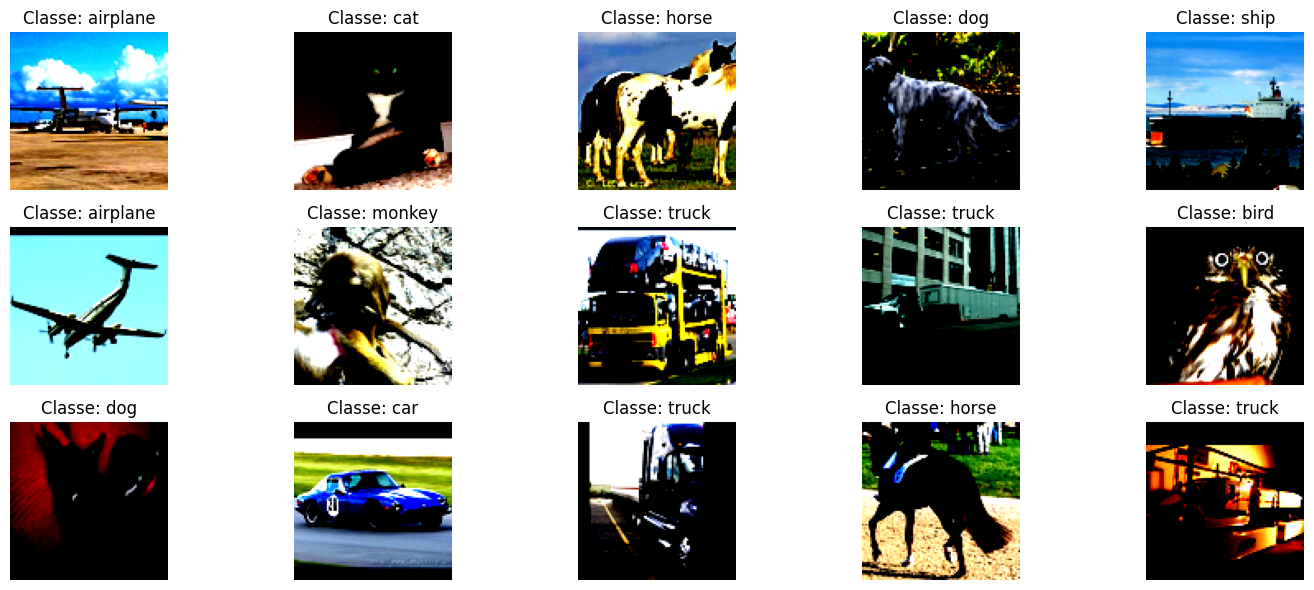


Dimensions d'un lot ImageNet : torch.Size([64, 3, 96, 96])
Plage de valeurs des pixels dans le lot : -1.5926 à 2.1111


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Récupérer un seul lot du DataLoader
dataiter = iter(train_loader_stl10)
images, labels = next(dataiter)

# Number of images to display
num_to_display = 15

fig, axes = plt.subplots(3, 5, figsize=(15, 6))
axes = axes.flatten() # Aplatir la grille d'axes pour un parcours facile

classes_ids = list(range(10)) # Simple liste des IDs 0 à 9
classes_dict = {0: 'airplane', 1: 'bird', 2: 'car', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'horse', 7: 'monkey', 8: 'ship', 9: 'truck',}

print(f"Affichage de {num_to_display} images aléatoires du premier batch.")

for i in range(num_to_display):
    # Convertir le Tensor (C, H, W) en NumPy (H, W, C)
    image_np = images[i].numpy().transpose((1, 2, 0))

    ax = axes[i]
    # L'affichage d'ImageNet nécessite généralement une dénormalisation si vous avez appliqué une normalisation
    # Pour l'instant, si vous utilisez seulement ToTensor(), l'affichage est direct.
    ax.imshow(image_np)

    # Class ID
    ax.set_title(f"Classe: {classes_dict[labels[i].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Check the dimensions and pixel value range of the batch
print(f"\nDimensions d'un lot ImageNet : {images.shape}")
print(f"Plage de valeurs des pixels dans le lot : {images.min():.4f} à {images.max():.4f}")

### Choice of multiple ViT and CNN architectures

#### ViT

In [105]:
# Créons la classe de notre ViT il s'agit la d'une première version naïve avec seulement un encoder.
# J'utilise https://www.geeksforgeeks.org/deep-learning/building-a-vision-transformer-from-scratch-in-pytorch/ 
# Dans un second temps on s'appropriera le code et on complexifiera l'architecture de ce ViT

# Un ViT se compose notamment d'une couche de patch embbeding, positional encoding, Multi head attention layer
# img_size = 32
# in_channels = 3
# embed_dim = 768
# patch_size = 16
# num_heads=8
# depth=6
# mlp_dim=1024
# num_classes=100
# seq_len = (img_size // patch_size) ** 2  # Nombre de patches

class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x
    
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, seq_len):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len + 1, embed_dim))  # Adjusted for [CLS] token

    def forward(self, x):
        return x + self.pos_embed
    
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)  # ✓ batch_first=True

    def forward(self, x):
        return self.attn(x, x, x)[0]
    
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim):
        super().__init__()
        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.mlp = nn.Sequential(    # Feed Forward Network
            nn.Linear(embed_dim, mlp_dim),
            nn.ReLU(),
            nn.Linear(mlp_dim, embed_dim)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))  
        x = x + self.mlp(self.norm2(x))   
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size, patch_size, num_classes, embed_dim, num_heads, depth, mlp_dim):
        super().__init__()
        self.patch_embedding = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        self.pos_encoding = PositionalEncoding(embed_dim, (img_size // patch_size) ** 2)
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim) for _ in range(depth)
        ])
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.mlp_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embedding(x)
        cls_tokens = self.cls_token.expand(B, -1, -1) # CLS token for each image
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.pos_encoding(x)
        for block in self.transformer_blocks:
            x = block(x)
        x = self.mlp_head(x[:, 0])
        return x

In [194]:
def training_loop(model, optimizer, criterion, train_loader, test_loader, epochs):
    
    loss_liste = []
    val_loss_liste = []
    
    #Training loop
    for epoch in range(epochs):  # loop over epochs
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move to GPU if available
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        loss_liste.append(epoch_loss)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for batch_idx, (data, label) in enumerate(test_loader):
                data = data.to(device)
                label = label.to(device)
                recon_batch = model(data)  
                val_loss_batch = criterion(recon_batch, label)
                val_running_loss += val_loss_batch.item()
        
        epoch_val_loss = val_running_loss / len(test_loader)
        val_loss_liste.append(epoch_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss}, Val_Loss: {epoch_val_loss}")
    
    return loss_liste, val_loss_liste

In [195]:
epoch_num = 10

model_stl = VisionTransformer(
    img_size=96,  # STL-10 est 96x96
    patch_size=16,
    num_classes=10,  # STL-10 a 10 classes
    embed_dim= 8*32,
    num_heads=8,
    depth=6,
    mlp_dim=1024
).to(device)
model_cifar = VisionTransformer(
    img_size=32,  # CIFAR-10 est 32x32
    patch_size=16,
    num_classes=10,  # CIFAR-10 a 10 classes
    embed_dim= 8*32,
    num_heads=8,
    depth=6,
    mlp_dim=1024
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) #label_smoothing=0.1
optimizer_stl = optim.Adam(model_stl.parameters(), lr=0.001)
optimizer_cifar = optim.Adam(model_cifar.parameters(), lr=0.001)

loss_liste_stl, val_loss_liste_stl = training_loop(model=model_stl, optimizer=optimizer_stl, criterion=criterion, train_loader=train_loader_stl10, test_loader=test_loader_stl10, epochs=epoch_num)
loss_liste_cifar, val_loss_liste_cifar = training_loop(model=model_cifar, optimizer=optimizer_cifar, criterion=criterion, train_loader=train_loader_cifar10, test_loader=test_loader_cifar10, epochs=epoch_num)

Epoch [1/10], Loss: 2.5354589012604727, Val_Loss: 2.026259199142456
Epoch [2/10], Loss: 1.9223470023915739, Val_Loss: 1.8150799226760865
Epoch [3/10], Loss: 1.7397260680983337, Val_Loss: 1.8069148149490357
Epoch [4/10], Loss: 1.6703364004062702, Val_Loss: 1.9249393281936646
Epoch [5/10], Loss: 1.5619378180443486, Val_Loss: 1.9812273082733154
Epoch [6/10], Loss: 1.441718314267412, Val_Loss: 1.811907067298889
Epoch [7/10], Loss: 1.369840309589724, Val_Loss: 1.787709397315979
Epoch [8/10], Loss: 1.2869727928427201, Val_Loss: 1.8998972520828248
Epoch [9/10], Loss: 1.2242274970947942, Val_Loss: 1.837712173461914
Epoch [10/10], Loss: 1.1043371716632118, Val_Loss: 1.9604646625518798
Epoch [1/10], Loss: 1.918976025813071, Val_Loss: 1.6784408318845532
Epoch [2/10], Loss: 1.6099037453341667, Val_Loss: 1.61029199859764
Epoch [3/10], Loss: 1.526292492971396, Val_Loss: 1.5668817139879059
Epoch [4/10], Loss: 1.4731757189611645, Val_Loss: 1.5440194335164903
Epoch [5/10], Loss: 1.4241659388212902, Val

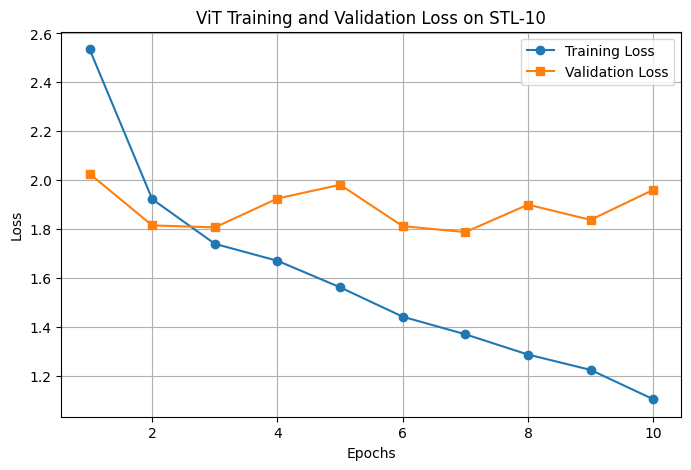

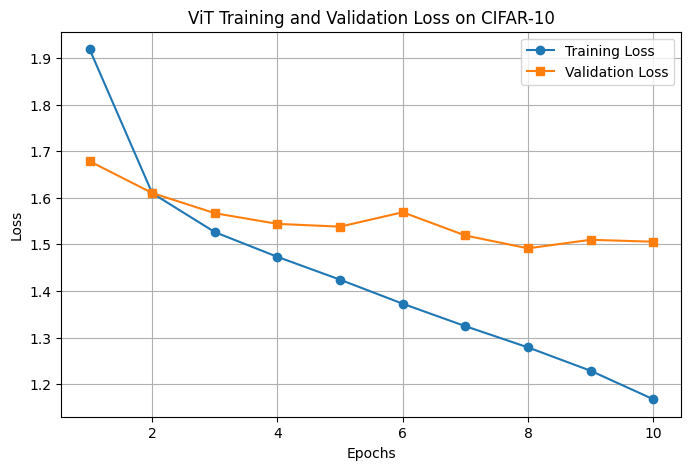

In [196]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epoch_num+1), loss_liste_stl, marker='o', label='Training Loss')
plt.plot(range(1, epoch_num+1), val_loss_liste_stl, marker='s', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ViT Training and Validation Loss on STL-10')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(1, epoch_num+1), loss_liste_cifar, marker='o', label='Training Loss')
plt.plot(range(1, epoch_num+1), val_loss_liste_cifar, marker='s', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ViT Training and Validation Loss on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()


In [198]:
def evaluate_and_visualize(model, test_loader, num_images, dataset_name):
    """
    Évalue le modèle sur l'ensemble de validation et affiche les prédictions avec les images.
    
    Args:
        model: Le modèle à évaluer
        test_loader: DataLoader pour l'ensemble de test
        num_images: Nombre d'images à afficher (par défaut 15)
        dataset_name: Nom du dataset pour les classes (par défaut "CIFAR-10")
    """
    
    # Classes CIFAR-10 et STL-10
    classes_cifar10 = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    classes_stl10 = ('airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck')
    
    # Dictionnaire pour mapper le nom du dataset aux classes
    classes_dict = {
        "CIFAR-10": classes_cifar10,
        "STL-10": classes_stl10
    }
    
    classes = classes_dict[dataset_name]
    
    model.eval()
    all_predictions = []
    all_labels = []
    all_images = []
    
    # Collecter les prédictions
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.append(predicted.cpu())
            all_labels.append(labels.cpu())
            all_images.append(images.cpu())
    
    # Convertir en tenseurs
    all_predictions = torch.cat(all_predictions, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    all_images = torch.cat(all_images, dim=0)
    
    # Calculer l'accuracy globale
    correct = (all_predictions == all_labels).sum().item()
    total = all_labels.size(0)
    accuracy = 100 * correct / total
    
    print(f"\n{'='*70}")
    print(f"RÉSULTATS DE VALIDATION - {dataset_name}")
    print(f"{'='*70}")
    print(f"Accuracy globale: {accuracy:.2f}% ({correct}/{total})")
    print(f"{'='*70}\n")
    
    # Afficher les images avec les prédictions
    num_rows = num_images // 5 + int(num_images % 5 != 0)
    num_cols = 5
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 9))
    axes = axes.flatten()
    
    for i in range(min(num_images, len(all_images))):
        image = all_images[i].numpy().transpose((1, 2, 0))
        true_label = all_labels[i].item()
        pred_label = all_predictions[i].item()
        
        # Afficher l'image
        axes[i].imshow(image)
        
        # Couleur verte si correct, rouge sinon
        is_correct = true_label == pred_label
        color = 'green' if is_correct else 'red'
        status = '✓' if is_correct else '✗'
        
        title = f"{status} Réel: {classes[true_label]}\nPrédit: {classes[pred_label]}"
        axes[i].set_title(title, color=color, fontweight='bold')
        axes[i].axis('off')
    
    # Masquer les subplots non utilisés
    for i in range(min(num_images, len(all_images)), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f"Prédictions du modèle ({num_images} images du dataset de validation)", 
                 fontsize=14, y=1.00)
    plt.show()
    
    # Statistiques par classe
    print(f"\nPrécision par classe:")
    print(f"{'-'*70}")
    for class_idx, class_name in enumerate(classes):
        class_mask = all_labels == class_idx
        if class_mask.sum() > 0:
            class_accuracy = (all_predictions[class_mask] == all_labels[class_mask]).sum().item() / class_mask.sum().item()
            class_count = class_mask.sum().item()
            print(f"{class_name:12} : {100*class_accuracy:6.2f}% ({(all_predictions[class_mask] == all_labels[class_mask]).sum().item()}/{class_count})")
    print(f"{'-'*70}\n")
    
    return all_predictions, all_labels, accuracy


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.476398..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2004358..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3166304..1.1670297].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..1.9077704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].



RÉSULTATS DE VALIDATION - STL-10
Accuracy globale: 42.54% (3403/8000)



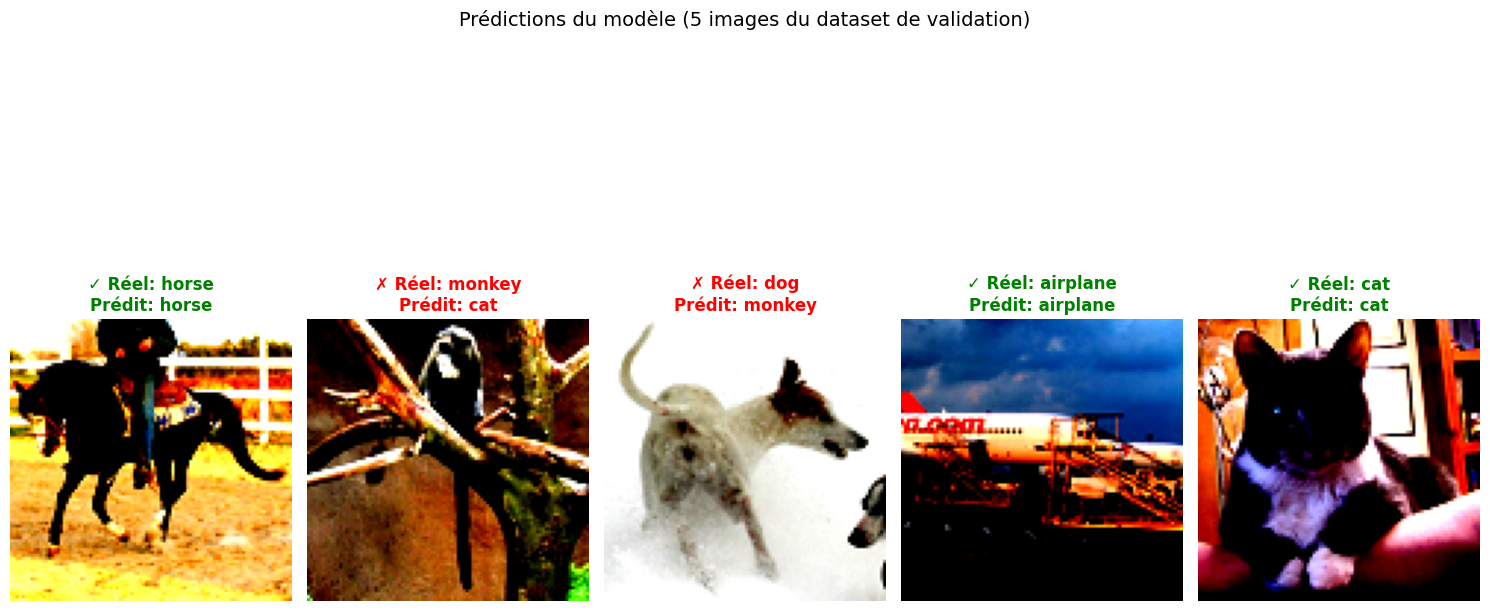


Précision par classe:
----------------------------------------------------------------------
airplane     :  51.12% (409/800)
bird         :  35.88% (287/800)
car          :  77.50% (620/800)
cat          :  40.88% (327/800)
deer         :  22.12% (177/800)
dog          :  16.12% (129/800)
horse        :  43.62% (349/800)
monkey       :  32.25% (258/800)
ship         :  76.12% (609/800)
truck        :  29.75% (238/800)
----------------------------------------------------------------------



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7830755..2.0942786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.9959002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9259666..2.0708537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4488223..1.801021].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8783362..1.5628136].



RÉSULTATS DE VALIDATION - CIFAR-10
Accuracy globale: 56.89% (5689/10000)



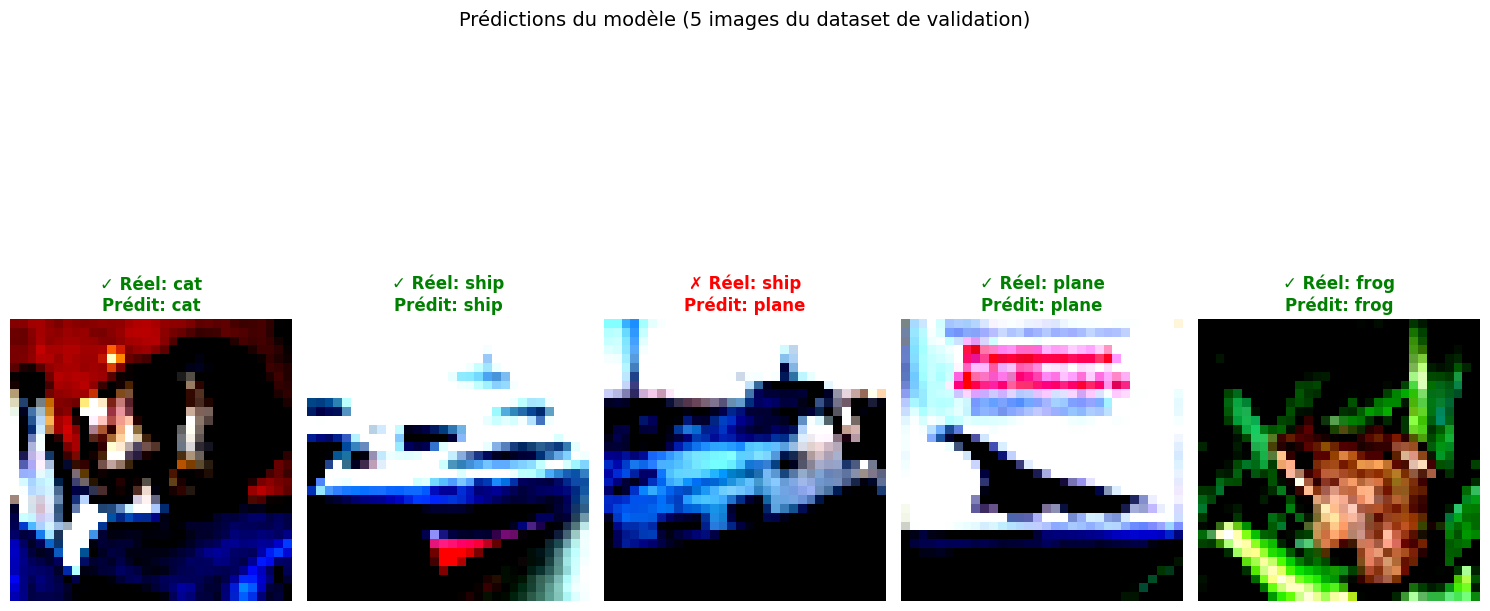


Précision par classe:
----------------------------------------------------------------------
plane        :  67.70% (677/1000)
car          :  62.80% (628/1000)
bird         :  43.70% (437/1000)
cat          :  38.00% (380/1000)
deer         :  45.90% (459/1000)
dog          :  53.60% (536/1000)
frog         :  62.50% (625/1000)
horse        :  61.90% (619/1000)
ship         :  67.80% (678/1000)
truck        :  65.00% (650/1000)
----------------------------------------------------------------------



In [199]:
# Évaluer et afficher les prédictions du modèle
predictions, true_labels, overall_accuracy = evaluate_and_visualize(
    model=model_stl, 
    test_loader=test_loader_stl10, 
    num_images=5,
    dataset_name="STL-10"
)

predictions, true_labels, overall_accuracy = evaluate_and_visualize(
    model=model_cifar, 
    test_loader=test_loader_cifar10, 
    num_images=5,
    dataset_name="CIFAR-10"
)


#### CNN

We choose to use a VGG16 model to compare it to ViT

In [200]:
import torch
import torch.nn as nn

class VGG16(nn.Module):

    def __init__(self, num_classes, dataset):
        super(VGG16, self).__init__()
        
        
        self.features = nn.Sequential(
            
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        # Classifier 
        # CIFAR (32x32) after 5 poolings, l'image fait 1x1. 
        # STL-10 (96x96), elle fera 3x3.
        if dataset == 'cifar10' :
            size = 1*1
        else :
            size = 3*3
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * size, 4096), # Ajust '1*1' or '3*3' selon le dataset
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [223]:
class CNN(nn.Module):
   def __init__(self, in_channels, num_classes):
       super(CNN, self).__init__()
       
       # Bloc 1: Conv -> Conv -> Pool
       self.conv1_1 = nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, padding=1)
       self.conv1_2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
       self.bn1 = nn.BatchNorm2d(32)
       self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       
       # Bloc 2: Conv -> Conv -> Pool
       self.conv2_1 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
       self.conv2_2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
       self.bn2 = nn.BatchNorm2d(64)
       
       # Bloc 3: Conv -> Conv -> Pool
       self.conv3_1 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
       self.conv3_2 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
       self.bn3 = nn.BatchNorm2d(128)
       
       # Adaptive average pooling pour normaliser la taille indépendamment de l'entrée
       self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
       
       # Couches fully connected avec dropout
       self.fc1 = nn.Linear(128, 256)
       self.dropout1 = nn.Dropout(0.5)
       self.fc2 = nn.Linear(256, 128)
       self.dropout2 = nn.Dropout(0.3)
       self.fc3 = nn.Linear(128, num_classes)

   def forward(self, x):
       # Bloc 1
       x = F.relu(self.bn1(self.conv1_1(x)))
       x = F.relu(self.conv1_2(x))
       x = self.pool(x)
       
       # Bloc 2
       x = F.relu(self.bn2(self.conv2_1(x)))
       x = F.relu(self.conv2_2(x))
       x = self.pool(x)
       
       # Bloc 3
       x = F.relu(self.bn3(self.conv3_1(x)))
       x = F.relu(self.conv3_2(x))
       x = self.pool(x)
       
       # Classification
       x = self.adaptive_pool(x)
       x = x.reshape(x.shape[0], -1)
       x = F.relu(self.dropout1(self.fc1(x)))
       x = F.relu(self.dropout2(self.fc2(x)))
       x = self.fc3(x)
       
       return x

In [224]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#model_cifar = VGG16(num_classes=10, dataset='cifar10').to(device)
#model_stl = VGG16(num_classes=10, dataset='stl10').to(device)

model_cifar = CNN(in_channels=3, num_classes=10).to(device)
model_stl = CNN(in_channels=3, num_classes=10).to(device)

In [225]:
import matplotlib.pyplot as plt

def train_model(model, train_loader, criterion, optimizer, num_epochs):
    model.train()
    history = {'loss': [], 'acc': []} # Pour stocker les métriques
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.3f} - Acc: {epoch_acc:.2f}%")
        
    return history

In [226]:
num_epochs = 10

criterion = nn.CrossEntropyLoss()
optimizer_stl = optim.SGD(model_stl.parameters(), lr=0.01, momentum=0.9)
optimizer_cifar = optim.SGD(model_cifar.parameters(), lr=0.01, momentum=0.9)

history_stl = train_model(model_stl, train_loader_stl10, criterion, optimizer_stl, num_epochs=10)
history_cifar = train_model(model_cifar, train_loader_cifar10, criterion, optimizer_cifar, num_epochs=10)

Epoch 1/10 - Loss: 2.230 - Acc: 14.48%
Epoch 2/10 - Loss: 1.814 - Acc: 25.54%
Epoch 3/10 - Loss: 1.704 - Acc: 28.92%
Epoch 4/10 - Loss: 1.665 - Acc: 30.70%
Epoch 5/10 - Loss: 1.630 - Acc: 31.58%
Epoch 6/10 - Loss: 1.626 - Acc: 30.92%
Epoch 7/10 - Loss: 1.575 - Acc: 33.92%
Epoch 8/10 - Loss: 1.588 - Acc: 34.26%
Epoch 9/10 - Loss: 1.567 - Acc: 34.98%
Epoch 10/10 - Loss: 1.545 - Acc: 34.84%
Epoch 1/10 - Loss: 1.838 - Acc: 27.81%
Epoch 2/10 - Loss: 1.360 - Acc: 48.60%
Epoch 3/10 - Loss: 1.126 - Acc: 59.12%
Epoch 4/10 - Loss: 0.962 - Acc: 65.85%
Epoch 5/10 - Loss: 0.862 - Acc: 69.87%
Epoch 6/10 - Loss: 0.777 - Acc: 72.85%
Epoch 7/10 - Loss: 0.711 - Acc: 75.48%
Epoch 8/10 - Loss: 0.648 - Acc: 77.73%
Epoch 9/10 - Loss: 0.605 - Acc: 79.71%
Epoch 10/10 - Loss: 0.553 - Acc: 81.30%


In [227]:
def plot_results(vgg_hist, dataset_name):
    epochs = range(1, len(vgg_hist['loss']) + 1)

    # Graphique de la Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, vgg_hist['loss'], 'b-', label='VGG16')
    plt.title(f'Loss sur {dataset_name}')
    plt.xlabel('Époques')
    plt.ylabel('Loss')
    plt.legend()

    # Graphique de l'Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, vgg_hist['acc'], 'b-', label='VGG16')
    plt.xlabel('Époques')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'results_{dataset_name}.png')

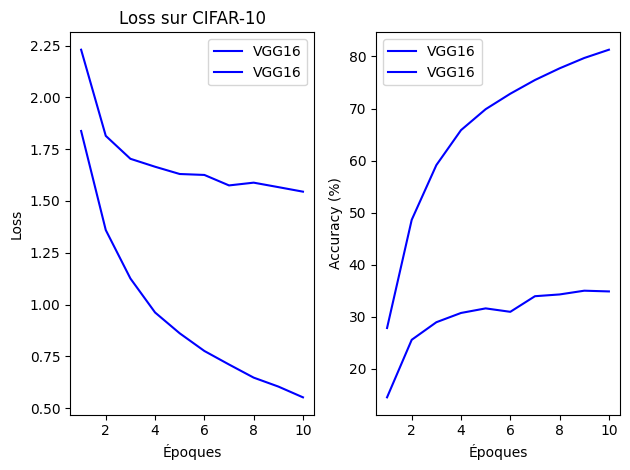

In [228]:
plot_results(history_stl, dataset_name='STL-10')
plot_results(history_cifar, dataset_name='CIFAR-10')

#### ResNet18 Pour Comparer l'efficatité en ayant plus de paramétres

In [207]:
# ResNet18 - Meilleure alternative que VGG16
from torchvision import models

# Créer les modèles ResNet18
resnet_cifar = models.resnet18(pretrained=False, num_classes=10).to(device)
resnet_stl = models.resnet18(pretrained=False, num_classes=10).to(device)

# Adaptations mineures pour les petites images
# Pour CIFAR-10 (32x32): remplacer le conv initial
resnet_cifar.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False).to(device)
resnet_cifar.maxpool = nn.Identity()  # Pas de maxpool pour images petites

# STL-10 (96x96): garder la config standard mais réduire stride
resnet_stl.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False).to(device)

print("ResNet18 créés")
print(f"Paramètres ResNet18: {sum(p.numel() for p in resnet_cifar.parameters()):,}")
print(f"Paramètres VGG16: {sum(p.numel() for p in model_cifar.parameters()):,}")
print(f"\nRatio: VGG16 / ResNet18 = {sum(p.numel() for p in model_cifar.parameters()) / sum(p.numel() for p in resnet_cifar.parameters()):.1f}×")

/home/emonteiro/.conda/envs/env_conda_Torch/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/emonteiro/.conda/envs/env_conda_Torch/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet18 créés
Paramètres ResNet18: 11,173,962
Paramètres VGG16: 33,638,218

Ratio: VGG16 / ResNet18 = 3.0×


In [208]:
# Entraîner ResNet18

criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet_stl = optim.SGD(resnet_stl.parameters(), lr=0.01, momentum=0.9)
optimizer_resnet_cifar = optim.SGD(resnet_cifar.parameters(), lr=0.01, momentum=0.9)

print("Entraînement ResNet18 sur STL-10...")
history_resnet_stl = train_model(resnet_stl, train_loader_stl10, criterion_resnet, optimizer_resnet_stl, num_epochs=10)

print("\nEntraînement ResNet18 sur CIFAR-10...")
history_resnet_cifar = train_model(resnet_cifar, train_loader_cifar10, criterion_resnet, optimizer_resnet_cifar, num_epochs=10)

Entraînement ResNet18 sur STL-10...
Epoch 1/10 - Loss: 1.866 - Acc: 27.86%
Epoch 2/10 - Loss: 1.550 - Acc: 42.04%
Epoch 3/10 - Loss: 1.309 - Acc: 51.52%
Epoch 4/10 - Loss: 1.187 - Acc: 56.90%
Epoch 5/10 - Loss: 0.945 - Acc: 65.02%
Epoch 6/10 - Loss: 0.668 - Acc: 76.48%
Epoch 7/10 - Loss: 0.536 - Acc: 82.12%
Epoch 8/10 - Loss: 0.478 - Acc: 83.50%
Epoch 9/10 - Loss: 0.331 - Acc: 88.36%
Epoch 10/10 - Loss: 0.163 - Acc: 94.86%

Entraînement ResNet18 sur CIFAR-10...
Epoch 1/10 - Loss: 1.436 - Acc: 47.51%
Epoch 2/10 - Loss: 0.935 - Acc: 66.82%
Epoch 3/10 - Loss: 0.653 - Acc: 76.94%
Epoch 4/10 - Loss: 0.448 - Acc: 84.35%
Epoch 5/10 - Loss: 0.289 - Acc: 89.96%
Epoch 6/10 - Loss: 0.168 - Acc: 94.20%
Epoch 7/10 - Loss: 0.104 - Acc: 96.48%
Epoch 8/10 - Loss: 0.060 - Acc: 98.10%
Epoch 9/10 - Loss: 0.036 - Acc: 98.85%
Epoch 10/10 - Loss: 0.027 - Acc: 99.11%


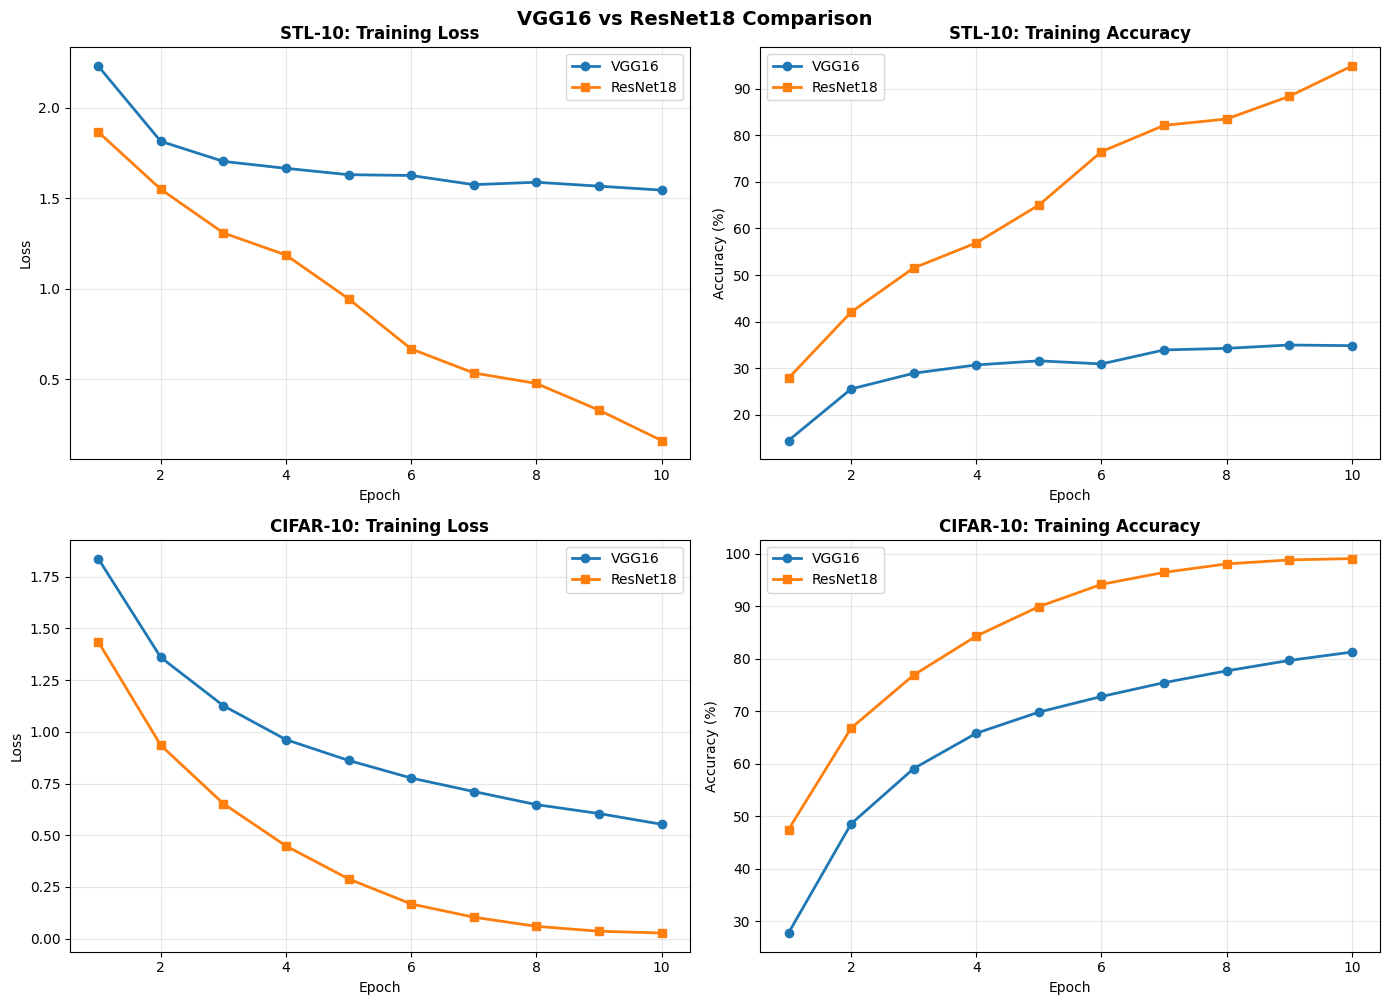


RÉSUMÉ: VGG16 vs ResNet18

STL-10 (après 10 epochs):
  VGG16   - Loss: 1.5450, Accuracy: 34.84%
  ResNet18 - Loss: 0.1630, Accuracy: 94.86%
  → ResNet18 meilleur de: +60.02%

CIFAR-10 (après 10 epochs):
  VGG16   - Loss: 0.5529, Accuracy: 81.30%
  ResNet18 - Loss: 0.0272, Accuracy: 99.11%
  → ResNet18 meilleur de: +17.81%

Paramètres:
  VGG16: 354,666
  ResNet18: 11,173,962
  → ResNet18 est 0.0× plus léger


In [229]:
# Comparaison VGG16 vs ResNet18

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# STL-10 Loss
axes[0, 0].plot(range(1, 11), history_stl['loss'], 'o-', label='VGG16', linewidth=2, markersize=6)
axes[0, 0].plot(range(1, 11), history_resnet_stl['loss'], 's-', label='ResNet18', linewidth=2, markersize=6)
axes[0, 0].set_title('STL-10: Training Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# STL-10 Accuracy
axes[0, 1].plot(range(1, 11), history_stl['acc'], 'o-', label='VGG16', linewidth=2, markersize=6)
axes[0, 1].plot(range(1, 11), history_resnet_stl['acc'], 's-', label='ResNet18', linewidth=2, markersize=6)
axes[0, 1].set_title('STL-10: Training Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# CIFAR-10 Loss
axes[1, 0].plot(range(1, 11), history_cifar['loss'], 'o-', label='VGG16', linewidth=2, markersize=6)
axes[1, 0].plot(range(1, 11), history_resnet_cifar['loss'], 's-', label='ResNet18', linewidth=2, markersize=6)
axes[1, 0].set_title('CIFAR-10: Training Loss', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# CIFAR-10 Accuracy
axes[1, 1].plot(range(1, 11), history_cifar['acc'], 'o-', label='VGG16', linewidth=2, markersize=6)
axes[1, 1].plot(range(1, 11), history_resnet_cifar['acc'], 's-', label='ResNet18', linewidth=2, markersize=6)
axes[1, 1].set_title('CIFAR-10: Training Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('VGG16 vs ResNet18 Comparison', fontsize=14, fontweight='bold', y=1.00)
plt.show()

# Résumé
print("\n" + "="*80)
print("RÉSUMÉ: VGG16 vs ResNet18")
print("="*80)
print(f"\nSTL-10 (après 10 epochs):")
print(f"  VGG16   - Loss: {history_stl['loss'][-1]:.4f}, Accuracy: {history_stl['acc'][-1]:.2f}%")
print(f"  ResNet18 - Loss: {history_resnet_stl['loss'][-1]:.4f}, Accuracy: {history_resnet_stl['acc'][-1]:.2f}%")
print(f"  → ResNet18 meilleur de: {history_resnet_stl['acc'][-1] - history_stl['acc'][-1]:+.2f}%")

print(f"\nCIFAR-10 (après 10 epochs):")
print(f"  VGG16   - Loss: {history_cifar['loss'][-1]:.4f}, Accuracy: {history_cifar['acc'][-1]:.2f}%")
print(f"  ResNet18 - Loss: {history_resnet_cifar['loss'][-1]:.4f}, Accuracy: {history_resnet_cifar['acc'][-1]:.2f}%")
print(f"  → ResNet18 meilleur de: {history_resnet_cifar['acc'][-1] - history_cifar['acc'][-1]:+.2f}%")

vgg_params = sum(p.numel() for p in model_cifar.parameters())
resnet_params = sum(p.numel() for p in resnet_cifar.parameters())
print(f"\nParamètres:")
print(f"  VGG16: {vgg_params:,}")
print(f"  ResNet18: {resnet_params:,}")
print(f"  → ResNet18 est {vgg_params/resnet_params:.1f}× plus léger")
print("="*80)